In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

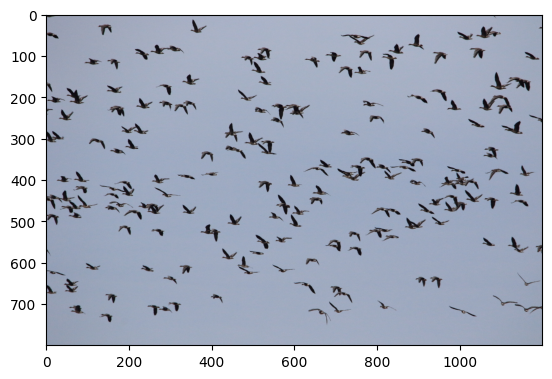

In [31]:
src = cv2.imread("images/birds.jpg")

plt.imshow(src[:,:,::-1])
plt.show()

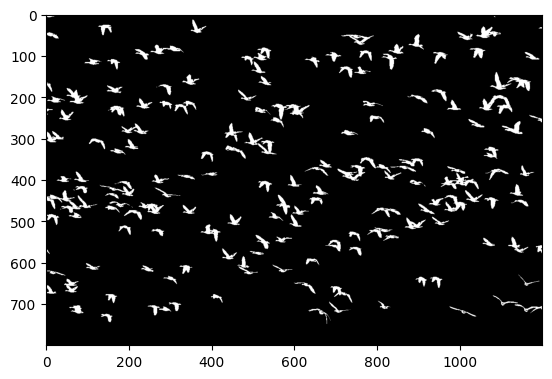

In [32]:
thr = 127
src = src[:,:,0]
img = np.where(src > thr , 0, 255)

plt.imshow(img, cmap= 'gray')
plt.show()

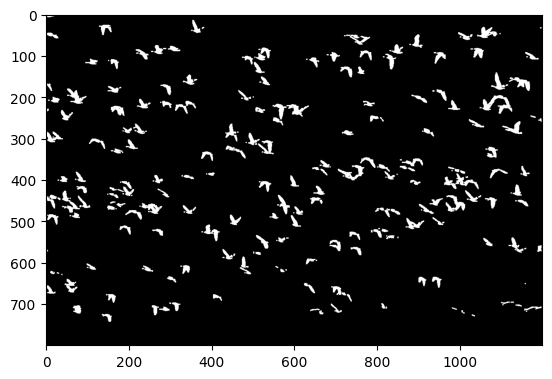

In [33]:
def erode_dil(src, mask_size, type):
    
    H = src.shape[0]
    W = src.shape[1]

    dst = np.zeros_like(src).astype(np.uint8)


    for h in range(1, H-1):
        for w in range(1, W-1):
            roi = src[h-1 : h-1+mask_size , w-1 : w-1+mask_size]

            if type == 'erode':
                dst[h,w] = np.min(roi)
            elif type == 'dil':
                dst[h,w] = np.max(roi)
    
    return dst

img_erode = erode_dil(img, 3, "erode")
img_open = erode_dil(img_erode, 3, "dil")

plt.imshow(img_open, cmap='gray')
plt.show()
    

In [38]:
def object_detect(image):
    H, W = image.shape[:2]
    counted = np.zeros((H, W), dtype=np.uint8)
    cnt = 0

    def is_in_bound(pixel):
        y, x = pixel
        return 0 <= y < H and 0 <= x < W

    def is_bg(pixel):
        y, x = pixel
        return image[y, x] == 0

    def is_counted(pixel):
        y, x = pixel
        return counted[y, x] == 1

    for h in range(H):
        for w in range(W):
            pixel = image[h, w]

            if pixel != 0 and counted[h, w] == 0:
                cnt += 1
                stack = [(h, w)]

                while len(stack) != 0:
                    y, x = stack.pop()
                    counted[y, x] = 1

                    for ny in range(y - 1, y + 2):
                        for nx in range(x - 1, x + 2):
                            neighbor = (ny, nx)

                            if is_in_bound(neighbor) and not is_bg(neighbor) and not is_counted(neighbor):
                                stack.append(neighbor)
    return cnt, counted

cnt, counted = object_detect(img_open) 

print(cnt) 

# counted 에 1이 체크된것이 다 물체
print(counted)

299
[[0 0 0 ... 0 0 0]
 [0 1 1 ... 0 0 0]
 [0 1 1 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
